# Topic modelling

## Importation des librairies et config

In [50]:
# Installation des bibliothèques pour colab
!pip install gensim nltk pyLDAvis pandas numpy matplotlib seaborn wordcloud

In [85]:
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt
import matplotlib
import matplotlib.cm as cm
import seaborn as sns
from wordcloud import WordCloud

import nltk
from nltk.corpus import stopwords
from gensim import corpora, models
from gensim.models import CoherenceModel
import pyLDAvis
import pyLDAvis.gensim_models as gensimvis
from collections import Counter

import warnings
warnings.filterwarnings("ignore", category=DeprecationWarning)
warnings.filterwarnings("ignore", category=FutureWarning)

nltk.download('stopwords', quiet=True)
%matplotlib inline

## Importation des données

In [ ]:
# Chargement
df_raw = pd.read_csv("data_texte.csv")

# Séparation en deux sous-groupes
df_femme = df_raw[df_raw['Genre'] == 'Femme'].copy()
df_homme = df_raw[df_raw['Genre'] == 'Homme'].copy()

print(f"Documents Femmes : {len(df_femme)}")
print(f"Documents Hommes : {len(df_homme)}")

Documents Femmes : 1863
Documents Hommes : 3742


## Prétraitement du texte

In [89]:
stop_words = set(stopwords.words('french'))
stop_words.update(['plus', 'tout', 'faire', 'être', 'avoir', 'aller', 'dire', 'donc', 'aussi', 'très', 'peut'])

def preprocess_french(text):
    if pd.isna(text): return []
    text = str(text).lower()
    # Garde lettres et accents
    text = re.sub(r'[^a-zàâçéèêëîïôûù\s]', ' ', text)
    tokens = text.split()
    return [t for t in tokens if t not in stop_words and len(t) > 3]

# Application
df_femme['tokens'] = df_femme['Phrase'].apply(preprocess_french)
df_homme['tokens'] = df_homme['Phrase'].apply(preprocess_french)

# Nettoyage des lignes vides après traitement
df_femme = df_femme[df_femme['tokens'].map(len) > 0]
df_homme = df_homme[df_homme['tokens'].map(len) > 0]

In [90]:
count_f = Counter([word for tokens in df_femme['tokens'] for word in tokens])
count_h = Counter([word for tokens in df_homme['tokens'] for word in tokens])

# Dictionnaire de référence : word -> 'F' ou 'H'
all_words = set(list(count_f.keys()) + list(count_h.keys()))
gender_pref = {word: ('F' if count_f[word] >= count_h[word] else 'H') for word in all_words}

## Entraînement du modèle LDA et évaluation de cohérence

In [78]:
def train_lda_with_coherence(texts, dictionary, corpus, n_topics=10):
    # Entraînement du modèle
    lda_model = models.LdaModel(
        corpus=corpus,
        id2word=dictionary,
        num_topics=n_topics,
        random_state=42,
        passes=10,
        alpha='auto'
    )

    # Calcul de la cohérence (Score C_V)
    coherence_model = CoherenceModel(
        model=lda_model,
        texts=texts,
        dictionary=dictionary,
        coherence='c_v'
    )
    coherence_score = coherence_model.get_coherence()

    return lda_model, coherence_score

In [79]:
# On crée d'abord d'abord le dictionnaire/corpus spécifiquement pour ce groupe
dict_f = corpora.Dictionary(df_femme['tokens'].tolist())
dict_f.filter_extremes(no_below=2, no_above=0.5)
corpus_f = [dict_f.doc2bow(t) for t in df_femme['tokens'].tolist()]

lda_femme, score_f = train_lda_with_coherence(df_femme['tokens'].tolist(), dict_f, corpus_f)
print(f"Score de cohérence Femmes : {score_f:.4f}")

Score de cohérence Femmes : 0.5446


In [80]:
# --- Exécution pour les Hommes ---
dict_h = corpora.Dictionary(df_homme['tokens'].tolist())
dict_h.filter_extremes(no_below=2, no_above=0.5)
corpus_h = [dict_h.doc2bow(t) for t in df_homme['tokens'].tolist()]

lda_homme, score_h = train_lda_with_coherence(df_homme['tokens'].tolist(), dict_h, corpus_h)
print(f"Score de cohérence Hommes : {score_h:.4f}")

Score de cohérence Hommes : 0.6223


## Visualisation avec pyLDAvis

In [81]:
# Export Femmes
vis_f = gensimvis.prepare(lda_femme, corpus_f, dict_f)
pyLDAvis.save_html(vis_f, 'topics_femmes.html')

# Export Hommes
vis_h = gensimvis.prepare(lda_homme, corpus_h, dict_h)
pyLDAvis.save_html(vis_h, 'topics_hommes.html')

print("Fichiers HTML générés : topics_femmes.html et topics_hommes.html")

Fichiers HTML générés : topics_femmes.html et topics_hommes.html


## Nuage de mots

In [105]:
titles_f = {
    0: "Technologie Hybride",       # Commun (M1)
    1: "Transition Électrique",     # Commun (M9)
    2: "Quotidien & Famille",       # Spécifique Femme
    3: "Offres & Financements",     # Commun (M6)
    4: "Évasion & Duster",          # Commun (M2)
    5: "Renouveau des Marques",     # Spécifique Femme
    6: "Mobilité Urbaine",          # Commun (M8)
    7: "Design & Séduction",        # Spécifique Femme
    8: "Plaisir de Conduire",       # Commun (M7)
    9: "Budget & Accessibilité"     # Spécifique Femme
}

titles_h = {
    0: "Gamme SUV & Innovation",    # Spécifique Homme
    1: "Technologie Hybride",       # Commun (F0)
    2: "Évasion & Duster",          # Commun (F4)
    3: "Expérience de Voyage",      # Spécifique Homme
    4: "Électrification & Modèles", # Spécifique Homme
    5: "Aventure & Liberté (Jeep)", # Spécifique Homme
    6: "Offres & Financements",     # Commun (F3)
    7: "Plaisir de Conduire",       # Commun (F8)
    8: "Mobilité Urbaine",          # Commun (F6)
    9: "Transition Électrique"      # Commun (F1)
}


In [106]:
viridis_palette = cm.get_cmap('viridis', 5)
color_f = matplotlib.colors.rgb2hex(viridis_palette(1)) # Violet
color_h = matplotlib.colors.rgb2hex(viridis_palette(2)) # Vert

def custom_color_func(word, **kwargs):
    # Retourne la couleur selon la dominance globale calculée en section 3
    return color_f if gender_pref.get(word) == 'F' else color_h


--- MODÈLE FEMMES ---


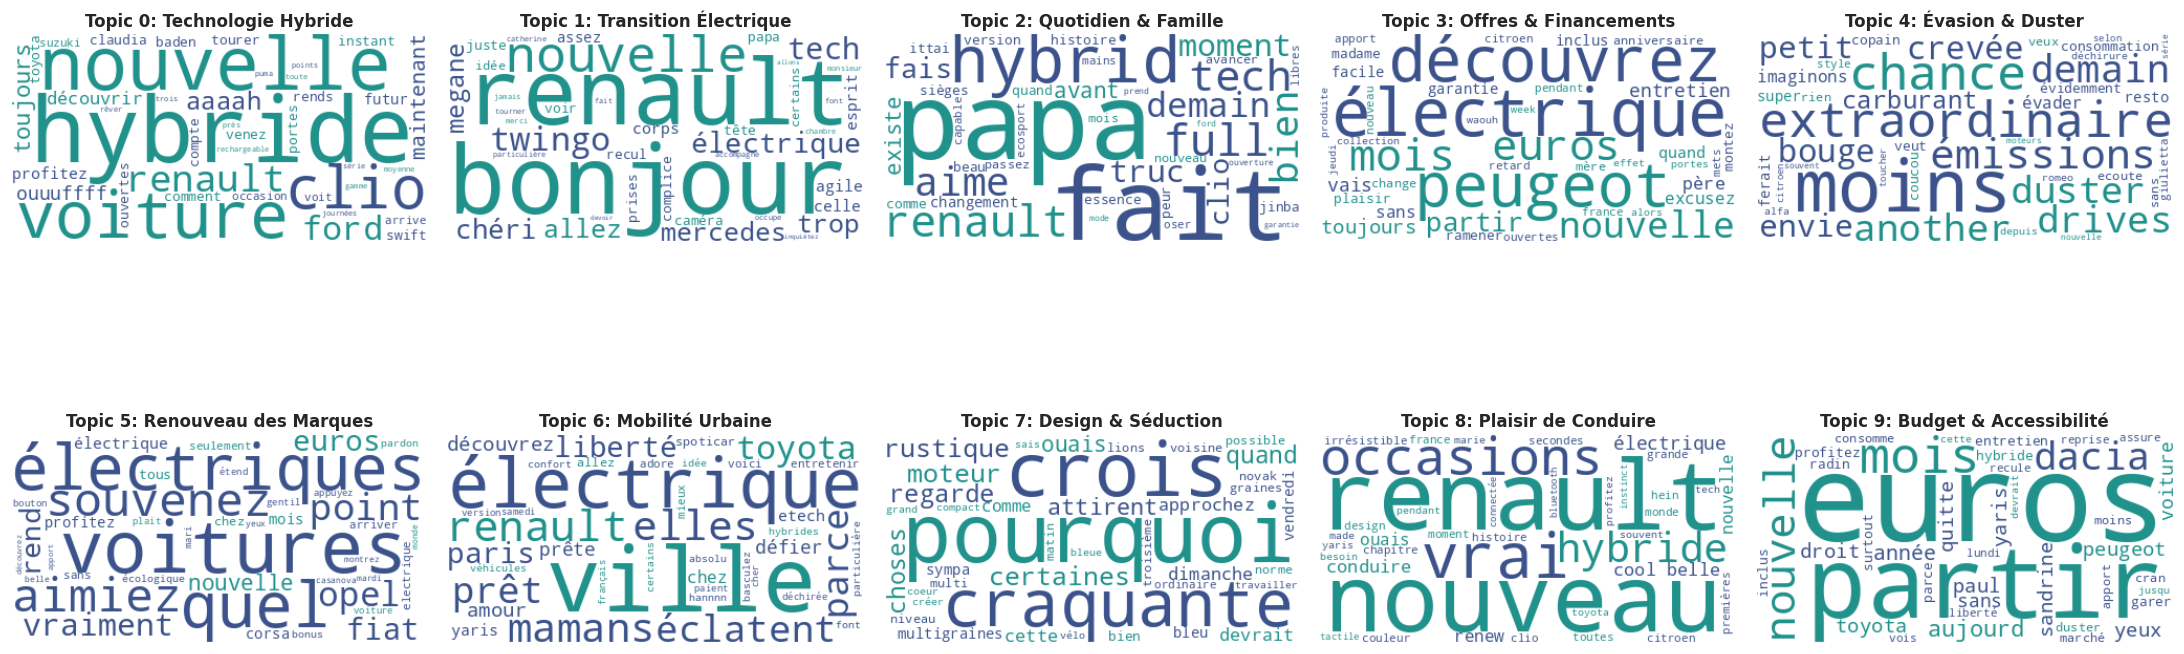


--- MODÈLE HOMMES ---


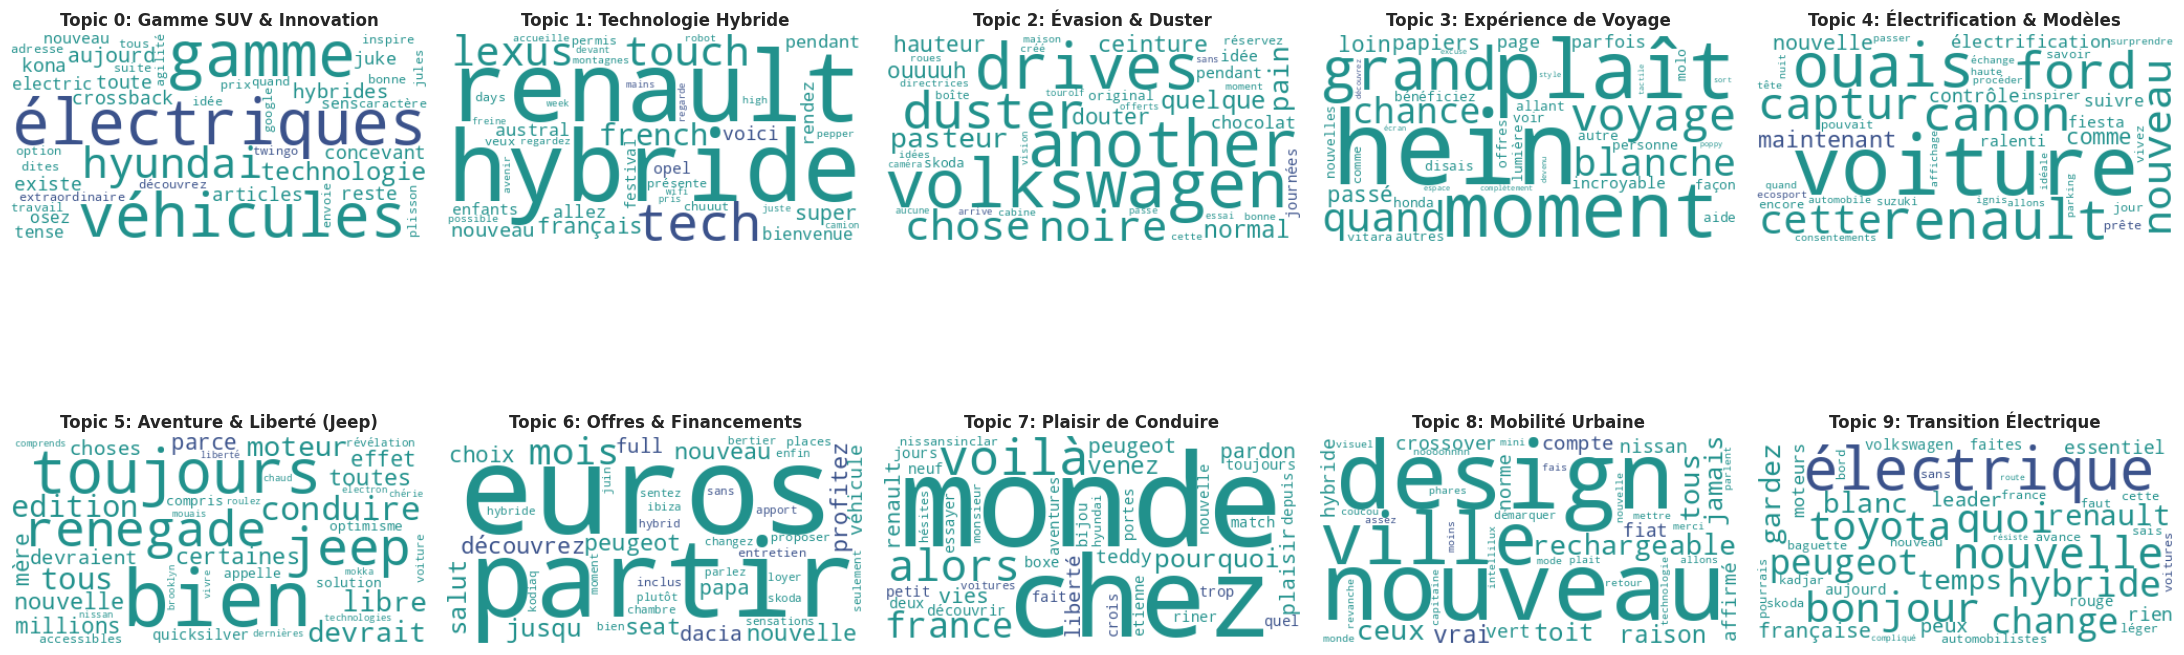

In [107]:
def plot_refined_wordclouds_with_titles(lda_model, n_topics, title_main, titles_dict):
    print(f"\n--- {title_main.upper()} ---")
    fig, axes = plt.subplots(2, 5, figsize=(22, 10))
    axes = axes.ravel()

    for i in range(n_topics):
        words = dict(lda_model.show_topic(i, 40))
        wc = WordCloud(background_color='white', color_func=custom_color_func).generate_from_frequencies(words)

        axes[i].imshow(wc, interpolation='bilinear')
        # On utilise le titre du dictionnaire
        axes[i].set_title(f"Topic {i}: {titles_dict[i]}", fontsize=12, fontweight='bold')
        axes[i].axis('off')

    plt.tight_layout()
    plt.show()

# Affichage des deux modèles avec leurs nouveaux noms
plot_refined_wordclouds_with_titles(lda_femme, 10, "Modèle Femmes", titles_f)
plot_refined_wordclouds_with_titles(lda_homme, 10, "Modèle Hommes", titles_h)